## HW Classification

In [14]:
#import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



In [15]:
#load the dataset
df=pd.read_csv("online_gaming_behavior_dataset (1).csv")

df.head(10)   # Print the first 10 rows 

# By looking at the dataset we can see the target variable is "Player Level" 

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
6,9006,25,Male,USA,Action,9.752716,0,Hard,1,50,13,2,Low
7,9007,25,Female,Asia,RPG,4.401729,0,Medium,10,48,27,23,Medium
8,9008,38,Female,Europe,Simulation,18.152733,0,Easy,5,101,23,41,Medium
9,9009,38,Female,Other,Sports,23.942772,0,Easy,13,95,99,36,High


In [16]:
df.info()   # To know about the null value and the data type of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [ ]:
# describe the dataset

df.describe() # To get the statistical summary of the dataset

#How to read this - the describe function gives the statistical summary of the numerical columns only.
# '''
# count - number of non-null values
# mean - average value
# std - standard deviation - tells how much data is spread out from the mean - high value means the data is spread out and low 
# value means the data is clustered around the mean 
# min - minimum value
# 25% - 25th percentile - value below which 25% of the data falls
# 50% - 50th percentile - value below which 50% of the data falls - also known as median - middle value of the data
# 75% - 75th percentile - value below which 75% of the data falls
# max - maximum value

# IQR= Inter Quartile Range = 75th percentile - 25th percentile - tells the range of the middle 50% of the data - CRUCIAL FOR OUTLIER DETECTION

# How to find outliers
# use the formula - 1.5*IQR
# any value outside the range of (25th percentile - 1.5*IQR) to (75th percentile + 1.5*IQR) is considered an outlier

# The data must be in the bounds of min and max value  like outlier range must be more than min and max value for no outliers to exist
# So in the dataset below there seem to be no outliers as the outlier range is within the min and max value





# Skewness from looking at the dataset
# Skewness tells how much the data is skewed to the left or right
# Rule of Thumb
# 1) Symmetrical - No Skew - Mean = Median 
# 2) Positively Skewed - Right Skew - Mean > Median
# 3) Negatively Skewed - Left Skew - Mean < Median




,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [17]:
# lets drop a column which is not required for analysis - in this case PlayerID
df=df.drop(columns=["PlayerID"])

In [ ]:
df.head() # We will no longer see the PlayerID column

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [ ]:
# Now lets check for the missing values in the dataset
df.isnull().sum() # this will tell the missing values in each column

# So we can see that there are no missing values in the dataset

Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

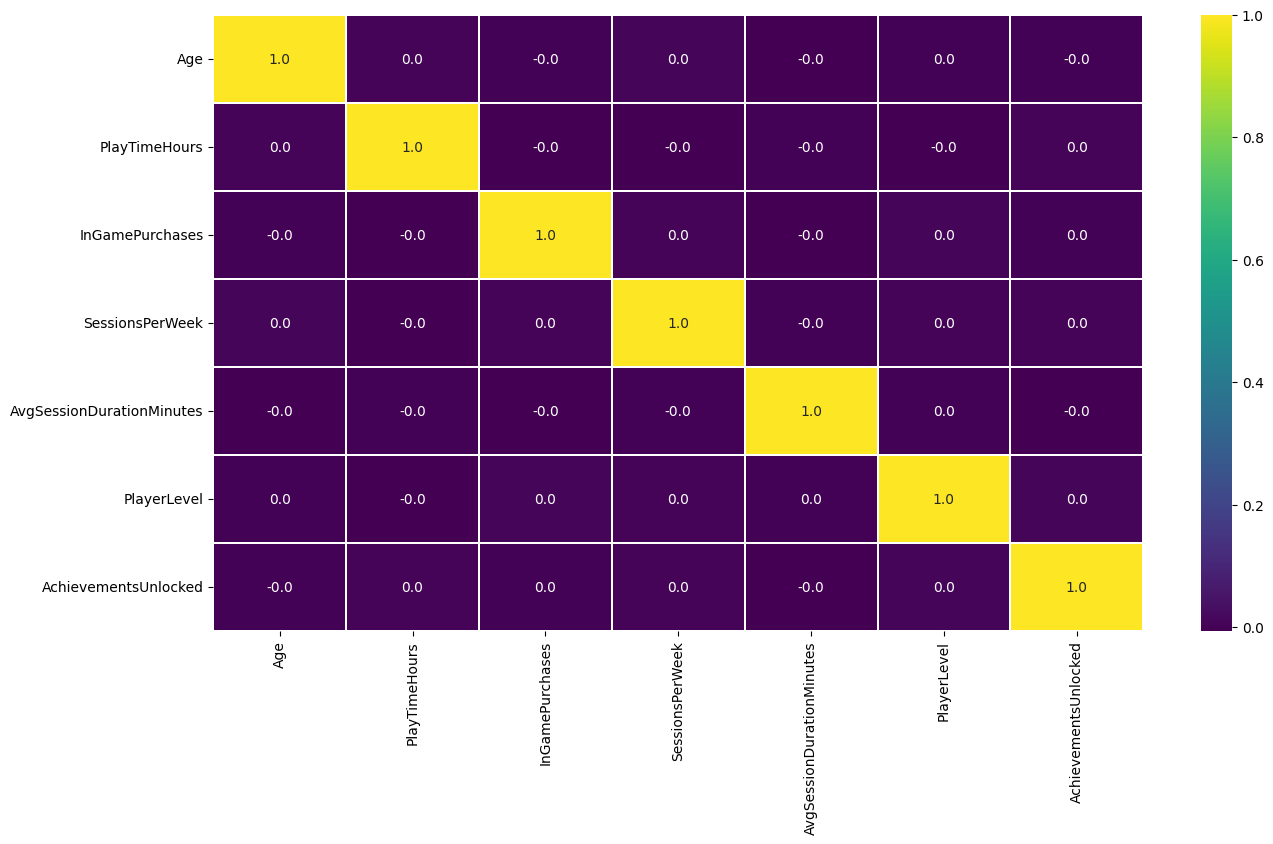

In [ ]:
# Plot the corelation heatmap to see the relation between features
corr_mat=df.corr(numeric_only=True)
plt.figure(figsize = (15,8))
sns.heatmap(corr_mat, annot = True, fmt= ".1f", linewidths = 0.25,cmap = 'viridis')
plt.show()

# This shows literally no relation between the features

In [43]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']

# ColumnTransformer with OneHotEncoder
ct = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
    remainder='drop'  # use 'passthrough' if you want to keep non-categorical columns
)

# Fit and transform
df_transformed = ct.fit_transform(df)

# Get feature names
encoded_col_names = ct.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Convert back to DataFrame
df_encoded = pd.DataFrame(df_transformed.toarray() if hasattr(df_transformed, "toarray") else df_transformed,
                          columns=encoded_col_names)

print(df_encoded.head())


   Gender_0  Gender_1  Location_Asia  Location_Europe  Location_Other  \
0       0.0       1.0            0.0              0.0             1.0   
1       1.0       0.0            0.0              0.0             0.0   
2       1.0       0.0            0.0              0.0             0.0   
3       0.0       1.0            0.0              0.0             0.0   
4       0.0       1.0            0.0              1.0             0.0   

   Location_USA  GameGenre_Action  GameGenre_RPG  GameGenre_Simulation  \
0           0.0               0.0            0.0                   0.0   
1           1.0               0.0            0.0                   0.0   
2           1.0               0.0            0.0                   0.0   
3           1.0               1.0            0.0                   0.0   
4           0.0               1.0            0.0                   0.0   

   GameGenre_Sports  GameGenre_Strategy  GameDifficulty_Easy  \
0               0.0                 1.0             

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        40034 non-null  int64  
 1   Gender                     40034 non-null  int64  
 2   Location                   40034 non-null  object 
 3   GameGenre                  40034 non-null  object 
 4   PlayTimeHours              40034 non-null  float64
 5   InGamePurchases            40034 non-null  int64  
 6   GameDifficulty             40034 non-null  object 
 7   SessionsPerWeek            40034 non-null  int64  
 8   AvgSessionDurationMinutes  40034 non-null  int64  
 9   PlayerLevel                40034 non-null  int64  
 10  AchievementsUnlocked       40034 non-null  int64  
 11  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(4)
memory usage: 3.7+ MB


In [45]:
# So we can now split the dataset into features and target variable 

X=df.drop(columns=["PlayerLevel"]) # Features
y=df['PlayerLevel'] # Target Variable



In [46]:
# Now split the dataset into training and testing set

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)


(32027, 11)


In [39]:
# Define the pipeline steps
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('log_reg',LogisticRegression())
])

pipeline.fit(X_train,y_train) # Train the model - Fit Pipeline

ValueError: could not convert string to float: 'USA'